# Tyre Degradation Analysis
Modelling how lap times evolve over a stint using F1 lap time data.
Dataset: Ergast F1 CSV (Rohan Rao / Kaggle)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

plt.style.use('dark_background')

laps = pd.read_csv("data/lap_times.csv", na_values="\\N")
print(laps.shape)
print(laps.head())

(589081, 6)
   raceId  driverId  lap  position      time  milliseconds
0     841        20    1         1  1:38.109         98109
1     841        20    2         1  1:33.006         93006
2     841        20    3         1  1:32.713         92713
3     841        20    4         1  1:32.803         92803
4     841        20    5         1  1:32.342         92342


In [18]:
races = pd.read_csv("data/races.csv", na_values="\\N")
print(races.tail(20))

      raceId  year  round  circuitId                       name        date  \
1105    1125  2024      5         17         Chinese Grand Prix  2024-04-21   
1106    1126  2024      6         79           Miami Grand Prix  2024-05-05   
1107    1127  2024      7         21  Emilia Romagna Grand Prix  2024-05-19   
1108    1128  2024      8          6          Monaco Grand Prix  2024-05-26   
1109    1129  2024      9          7        Canadian Grand Prix  2024-06-09   
1110    1130  2024     10          4         Spanish Grand Prix  2024-06-23   
1111    1131  2024     11         70        Austrian Grand Prix  2024-06-30   
1112    1132  2024     12          9         British Grand Prix  2024-07-07   
1113    1133  2024     13         11       Hungarian Grand Prix  2024-07-21   
1114    1134  2024     14         13         Belgian Grand Prix  2024-07-28   
1115    1135  2024     15         39           Dutch Grand Prix  2024-08-25   
1116    1136  2024     16         14         Italian

In [19]:
british_gp = laps[laps['raceId'] == 1132].copy()

print(british_gp.shape)
print(british_gp['driverId'].unique())

(960, 6)
[847   1 830 846 857 832 840 844 807   4 852 848 858 855 817 839 825 822
 815]


In [20]:
british_gp['seconds'] = british_gp['milliseconds'] / 1000

verstappen = british_gp[british_gp['driverId'] == 830].copy()

print(verstappen[['lap', 'seconds']].head(25))

        lap  seconds
575114    1   96.711
575115    2   91.773
575116    3   92.200
575117    4   91.933
575118    5   91.778
575119    6   91.711
575120    7   91.935
575121    8   92.038
575122    9   91.883
575123   10   91.661
575124   11   91.810
575125   12   91.894
575126   13   91.759
575127   14   91.700
575128   15   92.249
575129   16   92.504
575130   17   95.359
575131   18   96.172
575132   19  102.485
575133   20   97.108
575134   21   93.488
575135   22   91.904
575136   23   92.143
575137   24   93.020
575138   25   96.063


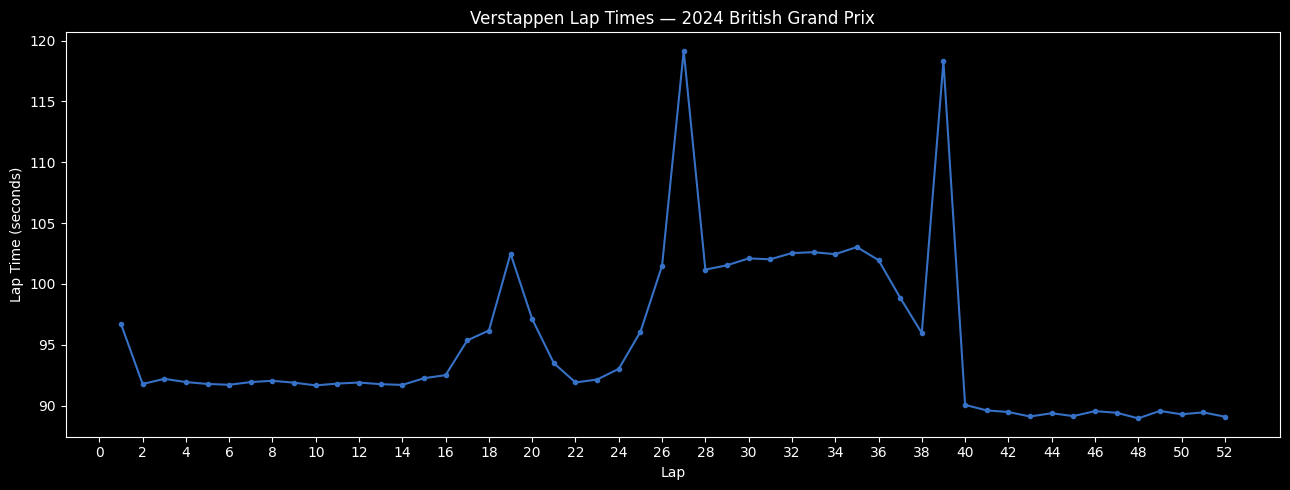

In [75]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(verstappen['lap'], verstappen['seconds'], color='#3671C6', linewidth=1.5, marker='o', markersize=3)

ax.set_xticks(range(0, len(verstappen) + 1, 2))

ax.set_xlabel("Lap")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title("Verstappen Lap Times — 2024 British Grand Prix")

plt.tight_layout()
plt.show()

In [76]:
pit_stops = pd.read_csv("data/pit_stops.csv", na_values="\\N")

verstappen_pits = pit_stops[
    (pit_stops['raceId'] == 1132) & 
    (pit_stops['driverId'] == 830)
].copy()

print(verstappen_pits[['lap', 'duration', 'milliseconds']])

       lap duration  milliseconds
10951   26   28.365         28365
10974   38   29.076         29076


In [77]:
print(verstappen[verstappen['lap'].isin([25, 26, 27, 37, 38, 39, 40])][['lap', 'seconds']])

        lap  seconds
575138   25   96.063
575139   26  101.491
575140   27  119.169
575150   37   98.869
575151   38   95.963
575152   39  118.311
575153   40   90.056


In [78]:
stint1 = verstappen[(verstappen['lap'] >= 2) & (verstappen['lap'] <= 26)].copy()
stint2 = verstappen[(verstappen['lap'] >= 28) & (verstappen['lap'] <= 38)].copy()
stint3 = verstappen[(verstappen['lap'] >= 40)].copy()

stint1['tyre_age'] = range(1, len(stint1) + 1)
stint2['tyre_age'] = range(1, len(stint2) + 1)
stint3['tyre_age'] = range(1, len(stint3) + 1)

print(f"Stint 1: {len(stint1)} laps")
print(f"Stint 2: {len(stint2)} laps")
print(f"Stint 3: {len(stint3)} laps")

Stint 1: 25 laps
Stint 2: 11 laps
Stint 3: 13 laps
